# Black Boxes

Sooner or later someone will tell you that a model must be interpretable to be trustworthy, and
that black boxes have no place in medicine. The claim deserves a careful answer, because the
careless version of it has held back a great deal of useful work — and because the opposite,
careless in the other direction, is worse.

This book's position follows from everything in chapters 3 to 6: **trust in a predictive model
comes from how it was validated, not from whether you can read its parameters.** A model whose
coefficients you can recite but which was never tested on independent data is not trustworthy. A
model you cannot read at all, which has been externally validated in three cohorts, tested against
its plausible confounders and shown not to respond to the wrong things, is.

That is not an argument against interpretation. It is an argument about what interpretation is
*for*. It is for generating hypotheses, for detecting shortcuts, and for communicating with the
people who have to act on the model — not for establishing that the model works.

## Model-agnostic tools

Everything below treats the model as a function you can call. It does not matter whether it is a
ridge regression, a random forest or a neural network.

We will use a gradient boosting model as our black box, and the ridge model as a reference point.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
TARGET = 'Age'
FEATURES = [c for c in ixi.columns if c.endswith('_volume')]
ixi[FEATURES] = ixi[FEATURES].astype(float)   # partial dependence needs floats, not integers

train, test = train_test_split(ixi, test_size=0.3, random_state=42)

ridge = Pipeline([('standardize', StandardScaler()), ('regression', Ridge(alpha=100))])
forest = HistGradientBoostingRegressor(max_depth=3, max_iter=300, learning_rate=0.05,
                                       random_state=42)

for name, estimator in [('ridge', ridge), ('gradient boosting', forest)]:
    estimator.fit(train[FEATURES], train[TARGET])
    print(f'{name:18s} test MAE: {mean_absolute_error(test[TARGET], estimator.predict(test[FEATURES])):.2f} years')

ridge              test MAE: 9.66 years


gradient boosting  test MAE: 8.66 years


### Permutation importance

We met this on [the previous page](classical.ipynb): shuffle a feature and measure the damage. Its
great virtue is that it applies unchanged to any model, and that it measures what the model *uses*
rather than what it contains.

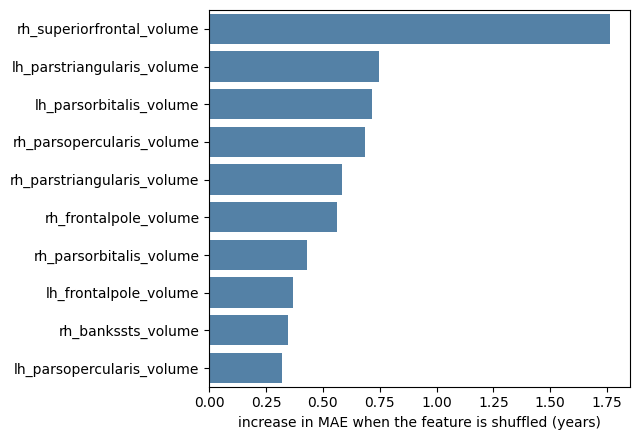

In [2]:
importance = permutation_importance(forest, X=test[FEATURES], y=test[TARGET],
                                    scoring='neg_mean_absolute_error',
                                    n_repeats=20, random_state=42, n_jobs=-1)

ranked = pd.Series(importance.importances_mean, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(6.5, 4.5))
sns.barplot(x=ranked.head(10).values, y=ranked.head(10).index, color='steelblue')
plt.xlabel('increase in MAE when the feature is shuffled (years)')
plt.ylabel('')
plt.tight_layout()
plt.show()

```{warning}
Permutation importance shuffles one feature while holding the others fixed, which creates
participants who do not exist: a tiny superior frontal cortex attached to an otherwise large brain.
The model is then evaluated on impossible data. With strongly correlated features — our situation
exactly — the resulting numbers can be badly misleading, and importance tends to be spread thinly
across correlated groups so that nothing looks important. Grouped permutation, where a whole
correlated cluster is shuffled together, is the usual remedy.
```

### Partial dependence

A second question: not *how much* does the model use a feature, but *how*? Partial dependence
sweeps one feature across its range, averaging the model's predictions over the observed values of
everything else.

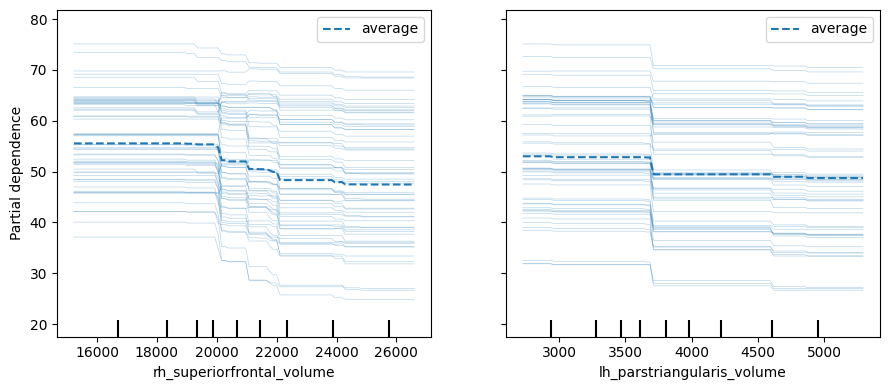

In [3]:
top_two = list(ranked.head(2).index)

fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(forest, test[FEATURES], features=top_two,
                                        kind='both', subsample=60, random_state=42, ax=ax)
plt.tight_layout()
plt.show()

The thick line is the average relationship the model has learned; the thin lines are individual
participants (an *ICE* plot, for individual conditional expectation). Two things are worth reading
off such a plot. Is the relationship monotone and plausible, or does it wiggle in ways that suggest
fitting noise? And do the individual curves run parallel to the average, or do they fan out — which
would indicate that the effect of this feature depends on the others.

Partial dependence inherits the same flaw as permutation importance, for the same reason: it
averages over combinations of features that never occur in reality.

### Local explanations

Permutation importance and partial dependence describe the model *globally*. Clinically, the
question is usually local: *why did it say that about this patient?* The established tools here are
LIME, which fits a simple model in the neighbourhood of one prediction, and SHAP, which
distributes a prediction among the features using a game-theoretic allocation with attractive
formal properties.

They are genuinely useful, and they come with the same caveat in a sharper form. A local
explanation is a statement about the model's behaviour near one point. It is not a statement about
the patient, and it is not evidence that the model is right about them. Two models with
indistinguishable predictive performance can produce quite different explanations for the same
individual, because they found different, equally predictive, combinations of correlated features.

## What explanation is good for

**Detecting shortcuts.** This is the strongest practical case. If your pneumonia classifier turns
out to be reading the portable-scanner marker on the X-ray, an importance analysis or a saliency
map will show you — and nothing in your cross-validated accuracy will. Interpretation is a
hypothesis generator for the confounder tests of
[chapter 6](../6_validity/validity.ipynb), and those tests are what settle the question.

**Generating scientific hypotheses.** A forward pattern showing that the model leans on frontal
regions is a reason to go and study frontal regions. It is not itself a finding about the brain.

**Communicating with the people affected.** A clinician deciding whether to act on a score needs
something to reason about, and a patient may have a right to an explanation of a decision that
concerns them. These are real requirements, and they are not satisfied by a validation table.

## What it is not good for

**Establishing that the model works.** Only validation does that.

**Establishing causation.** An importance ranking says what the model uses, not what would happen
if you changed something in the world.

**Reassurance.** A plausible-looking explanation of a broken model is worse than no explanation,
because it manufactures confidence. This is the real danger of explainability tools: they almost
always return *something*, and what they return almost always looks meaningful.

## So: are black boxes acceptable?

The honest answer depends on the job.

When the model's output drives a **decision with a known cost structure** and it has been validated
in the population where it will be used, opacity is tolerable — as it is for plenty of drugs whose
mechanism is not understood. The evidence is in the trial, not the mechanism.

When the model is meant as a **scientific claim** about how something works, opacity is the whole
problem: an uninterpretable model is not a theory, and no amount of accuracy makes it one.

And when the decision is **contestable** — when a person must be able to challenge it — an
explanation is an ethical requirement independent of whether it improves accuracy.

There is also a middle route that is too often forgotten: ask whether you need the black box at
all. On tabular biomedical data of the size we usually have, a well-tuned linear model is often
competitive — though not always, and note that the gradient boosting model above beat our
(untuned) ridge by a full year. [Chapter 8](../8_complex_models/index.md) runs that comparison
properly. If a simple model performs as well, the interpretability debate is moot, and you should
take the simple model; if it does not, you have measured what the opacity is buying you, which is
the right basis for the argument.

:::{admonition} Exercise 7.3
:class: tip, dropdown
Compare the top ten features by permutation importance for the ridge model and for the gradient
boosting model. How much do the lists overlap? What would it mean for your scientific conclusions
if two models with nearly identical accuracy disagreed about which regions matter?

:::{admonition} Solution
:class: note, dropdown
The overlap is usually partial. Since both models predict about equally well, neither list can be
"the" set of important regions — the data simply does not determine a unique answer, because the
features are redundant. The right conclusion is not to pick the list you prefer, but to report that
the importance ranking is not identifiable from these data, and to design a study that can settle
it if it matters.
:::
:::

:::{admonition} Exercise 7.4
:class: tip, dropdown
Deliberately build a shortcut. Add a new feature to the dataset that is simply `age + noise`,
refit, and confirm that the model's accuracy jumps. Now check whether permutation importance
reveals the culprit. Then imagine the shortcut had been something plausible-looking, such as
scanner ID.
:::